# GARCH(1,1) baseline - gold

Fits a GARCH(1,1) model to gold's daily returns and looks at what it estimated. This is our baseline: a simple, well-understood volatility model to compare later, fancier models against.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

## Load and prepare returns

Same loading steps as notebook 01. One addition: we drop the first row (its return is NaN, since there's no prior day to compare to - GARCH can't handle missing values) and multiply returns by 100, so they're in percentage-point units (e.g. 1.5 instead of 0.015). This isn't a modeling choice, it's a numerical-stability trick: the optimizer that fits the model works more reliably on numbers around this size rather than tiny decimals.

In [2]:
gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
gold.index.name = "Date"

returns = gold["Close"].pct_change().dropna() * 100
returns.head()

Date
2010-01-05    0.035790
2010-01-06    1.591991
2010-01-07   -0.246505
2010-01-08    0.450091
2010-01-11    1.098225
Name: Close, dtype: float64

## Build and fit the model

`arch_model(...)` writes down the specification: a constant mean (mu), GARCH(1,1) for the variance equation, and normally-distributed noise. `.fit()` runs the maximum-likelihood search for omega, alpha, beta described earlier. `disp="off"` just silences the optimizer's step-by-step progress printout.

In [3]:
model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
result = model.fit(disp="off")
print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5923.51
Distribution:                  Normal   AIC:                           11855.0
Method:            Maximum Likelihood   BIC:                           11880.4
                                        No. Observations:                 4170
Date:                Fri, Aug 07 2026   Df Residuals:                     4169
Time:                        12:20:51   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0260  1.528e-02      1.703  8.857e-02 

## Reading the summary

In the output above, look for the "Volatility Model" table: `omega`, `alpha[1]`, and `beta[1]` are the omega, alpha, beta from the equation we walked through. The `P>|t|` column is a p-value - small (e.g. under 0.05) means that parameter is reliably different from zero, i.e. genuinely useful to the model rather than noise.

## Plot the fitted volatility against actual returns

`result.conditional_volatility` is the model's estimated sigma_t for every single day in our data (the in-sample fit). Plotting it alongside the actual returns should show it tracking the calm/stormy clustering pattern we saw back in notebook 01.

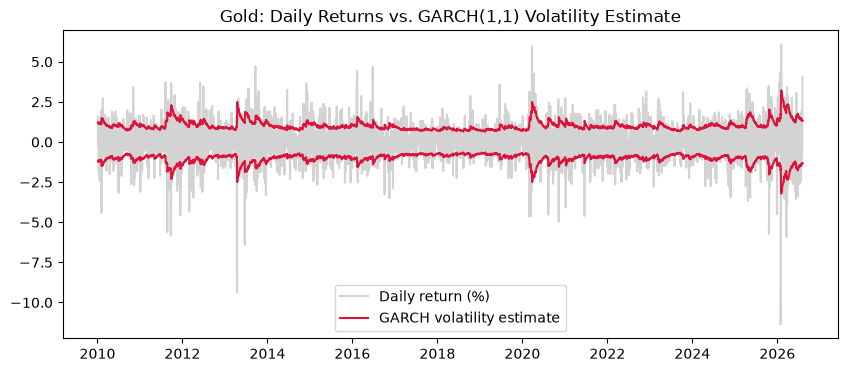

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(returns.index, returns, color="lightgray", label="Daily return (%)")
ax.plot(result.conditional_volatility.index, result.conditional_volatility, color="crimson", label="GARCH volatility estimate")
ax.plot(result.conditional_volatility.index, -result.conditional_volatility, color="crimson")
ax.set_title("Gold: Daily Returns vs. GARCH(1,1) Volatility Estimate")
ax.legend()
plt.show()